# HySwash: A hybrid method for nearshore wave processes

In [1]:
import os
import os.path as op
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import HTML

sys.path.insert(0, "..")
from utils.plotting import (
    animate_case_propagation,
    plot_depthfile,
    plot_scatters_Tp,
)
from utils.boundary_conditions import (
    get_real_scenarios_from_dataset,
)
#from utils.hyswash_wrapper import HySwashModelWrapper
import plotly.express as px
discrete_colors = px.colors.qualitative.Plotly


In [2]:
root_dir = os.getcwd()
output_dir = op.join(root_dir, "output")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")
os.makedirs(export_dir, exist_ok=True)

#os.environ["OMP_NUM_THREADS"] = "1"

<Axes: xlabel='Distance from offshore (m)', ylabel='Elevation (m)'>

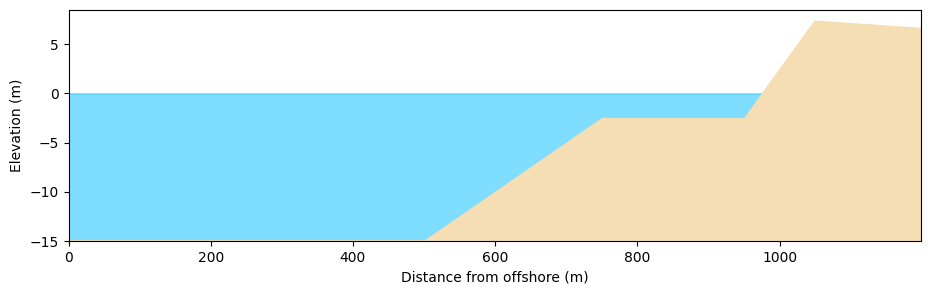

In [3]:
# Bathymetry parameters
h0 = 12  # offshore depth (m)
#bCrest = 5.0  # beach heigh (m)
#m = 12 / 300  # profile slope
#Wfore = 200  # flume length before fore toe (m)

# depth_array = reef(1, 20, 1/20, 1/20, 300, 500, 5, 2)
#depth_array = linear(1, h0, bCrest, m, Wfore)
# Cut the depth array to the desired length (600 meters)
#depth_array = depth_array[0:599]
#np.savetxt(op.join(templates_dir, "depth.bot"), depth_array)
depth_array = np.loadtxt(op.join(templates_dir, "depth.bot"))
plot_depthfile(depthfile=op.join(templates_dir, "depth.bot"))


### 1.1. Latin Hypercube Sampling (LHS)

The Latin Hypercube Sampling (LHS) is a statistical technique designed to efficiently select parameter values across multiple dimensions while ensuring controlled randomness in the sampled data. To implement this technique, we start by establishing the limits for each variable.

In [4]:
from bluemath_tk.datamining.lhs import LHS

variables_to_analyse_in_metamodel = ["Hs", "Hs_L0", "WL"]
lhs_parameters = {
    "num_dimensions": 3,
    "num_samples": 10000,
    "dimensions_names": variables_to_analyse_in_metamodel,
    "lower_bounds": [0.5, 0.003, 0, ],
    "upper_bounds": [3, 0.01, 2],
}

lhs = LHS(
    num_dimensions=lhs_parameters.get("num_dimensions"),
)

lhs_dataset = lhs.generate(
    dimensions_names=lhs_parameters.get("dimensions_names"),
    lower_bounds=lhs_parameters.get("lower_bounds"),
    upper_bounds=lhs_parameters.get("upper_bounds"),
    num_samples=lhs_parameters.get("num_samples"),
)

df_dataset = get_real_scenarios_from_dataset(lhs_dataset, h0)
df_dataset

,Hs,Hs_L0,WL
0,1.599622,0.004896,1.882771
1,2.643763,0.004351,0.432315
2,1.905543,0.006337,0.159290
3,2.091993,0.003412,1.317092
4,2.558418,0.006539,1.014539
...,...,...,...
9993,0.961571,0.009540,1.472808
9994,2.464722,0.005380,1.404871
9995,0.911084,0.004989,1.707223
9996,0.911421,0.003619,1.135342


### 1.2. Maximum Dissimilarity Algorithm (MDA)

The high computational cost of propagating the entire hindcast dataset requires statistical tools to reduce the set of data to a number of representative cases to perform hybrid downscaling. The maximum dissimilarity algorithm (MDA) defined in the work of Camus et al., 2011, is implemented for this purpose.<br>
    <br>
Given a data sample $X=\{x_{1},x_{2},…,x_{N}\}$ consisting of $N$ $n$-dimensional vectors, a subset of $M$ vectors $\{v_{1},…,v_{M}\}$ representing the diversity of the data is obtained by applying this algorithm. The selection starts initializing the subset by transferring one vector from the data sample ${v_{1}}$. The rest of the $M-1$ elements are selected iteratively, calculating the dissimilarity between each remaining data in the database and the elements of the subset and transferring the most dissimilar one to the subset. The process finishes when the algorithm reaches $M$ iterations.

⚠️ **Warning:** This Notebook was originally developed and run on a computing cluster. If you plan to run this Notebook in a more limited environment, such as GitHub CodeSpaces for exploratory or educational purposes, we recommend reducing MDA to 4. We also recommend set `scatter_points_thick = 10` to make scatter plots clearer and less cluttered.

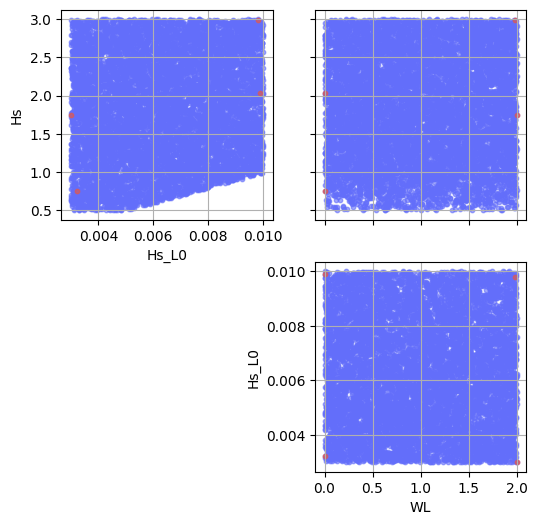

In [5]:
from bluemath_tk.datamining.mda import MDA

mda_samples = 4
scatter_points_thick = 10

mda_parameters = {"num_centers": mda_samples}

mda = MDA(num_centers=mda_parameters.get("num_centers"))
mda.fit(data=df_dataset, normalize_data=True)
[fig, axes] = mda.plot_selected_centroids(s=scatter_points_thick, 
                                          data_color=discrete_colors[0], 
                                          centroids_color=discrete_colors[1],
                                          )
fig.set_size_inches(6, 6)

mda._exclude_attributes = []
mda.save_model(
    model_path=op.join(export_dir, "mda_model.pkl"),
)

## 2. Numerical model SWASH

Once the hydrodynamic cases to be numerically simulated have been selected through the MDA algorithm, we proceed to launch these cases in SWASH. It is a versatile numerical tool designed to simulate a non-hydrostatic, phase-resolving wave model capable of simulating waves from deep waters to the shoreline, modeling wave breaking, bottom friction, wave- induced setup and runup, and the generation and propagation of infragravity waves (Delft University of Technology, n. d.).

The bottom-friction profile is a fixed configuration of the numerical model, not an input variable of the HySwash metamodel. Define it below using cross-shore zones `(x_start, x_end, value)`, or provide an existing one-column file. Zone intervals use profile coordinates in metres and follow `x_start <= x < x_end`.

In [6]:
from bluemath_tk.wrappers.swash.swash_wrapper import HySwashModelWrapper

metamodel_parameters = mda.centroids.to_dict(orient="list")

fixed_parameters = {
    "dxinp": 1,  # Bathymetry and friction grid spacing (m)
    "comptime": 300,  # Simulation duration (s)
    "warmup": 150,  # Warmup duration (s)
    "n_nodes_per_wavelength": 60,  # number of nodes per wavelength
    "Cf_ini": 100,
    "Cf_fin": 400,
    "Cf": 0.02
}

# Option A: define fixed friction zones here. Uncovered points use
# default_friction. Add as many non-overlapping zones as needed.
#friction_zones = [
#    (200, 400, 0.01),
#]

swash_model = HySwashModelWrapper(
    templates_dir=templates_dir,
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    depth_array=depth_array,
    templates_name=["INPUT", "depth.bot"],
    #friction_zones=friction_zones,
    default_friction=0.002,
    # Option B (instead of friction_zones):
    # friction_file=op.join(root_dir, "my_friction.txt"),
)
swash_model.save_model(model_path=op.join(export_dir, "swash_model.pkl"))


TypeError: SwashModelWrapper.__init__() got an unexpected keyword argument 'friction_zones'

### Build, run and postprocess cases

In [7]:
swash_model.build_cases()


In [8]:
swash_model.run_cases_in_background(launcher='serial', num_workers=2)


Monitor cases

In [13]:
swash_model.monitor_cases()


,Case,Status
0,0000,END
1,0001,END
2,0002,END
3,0003,END


In [10]:
sys.exit()

SystemExit: 

## 4. Data Processing

The primary output variable generated by SWASH include the time series of water level along the profile. This output serves as crucial indicator of the hydrodynamic processes. From this SWASH output, we compute various other key variables. Different output quantities will be given here to go over the different wave transformation processes including wave propagation, dispersion, flooding and drying, moving shoreline, surf-beat, infragravity waves, set-up induced by wave breaking, run-up and overtopping discharge. 

- To this end, the time-dependent surface elevation is stored at every grid point for every time step. After removing the warmup time from the sea surface series, a FFt is applied to obtain its representation in the frequency domain. A further classification is given by spliting the wave frequency into incident waves IC (0.04 - 1), infragravity waves IG (0.004 - 0.04) and very low frequency VLF (0.001 - 0.004). 

- The run-up heigh is computed by the intersection between free surface and bottom level considering a minimun  depth of 1cm after each time step. 

- The mean wave overtopping discharge q (ms/l) is outputted at the highest elevation point.

After each simulation, the postprocess steps creates 2 files in the directory of the case:
 
 - output.nc: It contains the case run.tab and output.tab in netCDF format.
 - output_postprocessed.nc: It contains the variables selected by the users. In our case: 'Ru2', 'Runlev', 'Msetup', 'Hrms', 'Hfreqs'.

The postprocessor also allows the creation of a single netCDF file with the postprocessed output of every case. It locates it in the output_dir.

In [8]:
swash_model.list_available_postprocess_vars()

['Ru2', 'Runlev', 'Msetup', 'Hrms', 'Hfreqs']

In [9]:
postprocessed_output = swash_model.postprocess_cases(write_output_nc=False)
postprocessed_output


2026-09-18 02:02:30,976 - HySwashModelWrapper - WARNING - Output postprocessed file already exists. Skipping postprocessing.


<xarray.Dataset> Size: 258kB
Dimensions:   (case_num: 4, Tsec: 450, Xp: 1200)
Coordinates:
  * case_num  (case_num) int64 32B 0 1 2 3
  * Tsec      (Tsec) int64 4kB 0 1 2 3 4 5 6 7 ... 443 444 445 446 447 448 449
  * Xp        (Xp) int64 10kB 0 1 2 3 4 5 6 ... 1194 1195 1196 1197 1198 1199
    Yp        int64 8B ...
Data variables:
    Ru2       (case_num) float64 32B ...
    Runlev    (case_num, Tsec) float64 14kB ...
    Msetup    (case_num, Xp) float64 38kB ...
    Hrms      (case_num, Xp) float64 38kB ...
    Hs        (case_num, Xp) float64 38kB ...
    Hss       (case_num, Xp) float64 38kB ...
    ig        (case_num, Xp) float64 38kB ...
    Hvlf      (case_num, Xp) float64 38kB ...

#### Plot postprocessed output for different cases

Choose the variable (Runlev, Msetup, Hrms, Hs, Hss, ig, Hvlf) and cases you want to visualize

In [10]:
mda.centroids

,Hs,Hs_L0,WL
0,2.987796,0.009801,1.979975
1,0.755032,0.003216,0.001873
2,1.743281,0.003004,1.998308
3,2.036879,0.009907,0.007371


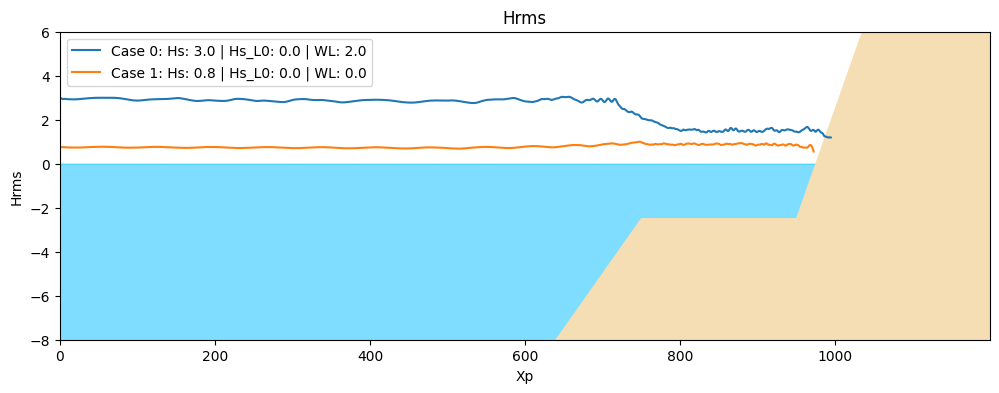

In [11]:
postprocessed_var = "Hrms"
cases = [0, 1]

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_depthfile(depthfile=op.join(templates_dir, "depth.bot"), ax=ax)
for case_num in cases:
    values = mda.centroids.iloc[case_num].to_dict()
    postprocessed_output.isel(case_num=case_num)[postprocessed_var].plot(
        ax=ax,
        label=f"Case {case_num}: {' | '.join(f'{k}: {v:.1f}' for k, v in values.items())}",
    )
ax.set_ylim(-8, 6)
ax.set_title(postprocessed_var)
ax.legend()

### Total Water Elevation Visualization
Fill case_num with the number of the simulation you want to visualize



In [13]:
case_num = 0

case_num_s = str(case_num).zfill(4)
output_nc = xr.open_dataset(op.join(output_dir, case_num_s, "output.nc"))
data = output_nc[["Watlev"]].squeeze()
ani = animate_case_propagation(
    data,
    depth_array + mda.centroids.iloc[case_num]["WL"],
    tini=0,
    tend=300,
    tstep=5,
    figsize=(11, 3),
)
HTML(ani.to_jshtml())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>
